# 실행환경 : COLAB H100

In [1]:
# 1. 기존 패키지 정리
!pip uninstall -y transformers accelerate bitsandbytes triton peft -q

# 2. 버전 명확히 고정해서 한 번에 설치
!pip install -q \
    transformers==4.44.2 \
    accelerate==0.34.2 \
    peft==0.11.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 12.3 MB/s eta 0:00:00


In [1]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# **Mobile VLM + Clip Text Encoder 불러오기**
- https://github.com/Meituan-AutoML/MobileVLM

> **Mobile VLM 불러오기**

In [2]:
%cd /content
!rm -rf MobileVLM
!git clone https://github.com/Meituan-AutoML/MobileVLM.git

/content
Cloning into 'MobileVLM'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 212 (delta 61), reused 41 (delta 41), pack-reused 128 (from 1)
Receiving objects: 100% (212/212), 474.57 KiB | 11.86 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [3]:
import sys
import torch
sys.path.append("/content/MobileVLM")

from mobilevlm.model.mobilevlm import load_pretrained_model

model_path = "mtgv/MobileVLM-3B"
tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path,
    device="cuda"
)

model.to(torch.bfloat16)
print(f"✅ 로드 성공! VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

tokenizer_config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/6.07G [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:754: UserWarning: for vision_model.embeddings.class_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:754: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:754: UserWarning: for vision_model.embeddings.posi

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

✅ 로드 성공! VRAM: 5.68 GB


> **Clip Text Encoder 불러오기**

- MobileVLM의 vision_tower는 Pretrain된 CLIP vision encoder에서 text encoder 부분을 제외한 파라미터를 그대로 사용한다.
- CLIP을 활용한 이미지-텍스트 간 유사도 계산을 하기 위해 Pretrained Clip에서 Text Encoder 부분만을 추가로 불러온다.

In [4]:
import torch
import torch.nn.functional as F
from transformers import (
    CLIPModel, CLIPTextModel, CLIPTokenizer, CLIPProcessor, CLIPConfig
)
from huggingface_hub import hf_hub_download
from PIL import Image

vision_tower = model.model.vision_tower
clip_vision_model = vision_tower.vision_tower

clip_ckpt = "openai/clip-vit-large-patch14-336"

# ------------------------------------------------------------------
# 1. 빈 CLIPModel 생성
# ------------------------------------------------------------------
clip_config = CLIPConfig.from_pretrained(clip_ckpt)
full_clip = CLIPModel(clip_config).to("cuda").to(torch.bfloat16)

# ------------------------------------------------------------------
# 2. vision_model: MobileVLM weights 직접 연결
# ------------------------------------------------------------------
stripped_sd = {
    (k[len("vision_model."):] if k.startswith("vision_model.") else k): v
    for k, v in clip_vision_model.state_dict().items()
}
full_clip.vision_model.load_state_dict(stripped_sd, strict=True)
print("✅ vision_model: MobileVLM weights 연결 완료")

# ------------------------------------------------------------------
# 3. text_model: CLIPTextModel만 다운로드
# ------------------------------------------------------------------
text_model = CLIPTextModel.from_pretrained(clip_ckpt, torch_dtype=torch.bfloat16).to("cuda")
full_clip.text_model.load_state_dict(text_model.text_model.state_dict(), strict=True)
del text_model
torch.cuda.empty_cache()
print("✅ text_model: 공식 CLIP text encoder 로드 완료")

# ------------------------------------------------------------------
# 4. projections + logit_scale: pytorch_model.bin에서 필요한 키만 추출
#    safetensors → pytorch_model.bin 순으로 시도
# ------------------------------------------------------------------
target_keys = {"visual_projection.weight", "text_projection.weight", "logit_scale"}
proj_sd = {}

def extract_from_bin(bin_path):
    """pytorch_model.bin에서 target_keys만 로드 (전체 메모리 로드 후 필터)"""
    sd = torch.load(bin_path, map_location="cpu")
    return {k: sd[k].to(torch.bfloat16) for k in target_keys if k in sd}

# 시도 순서: safetensors → pytorch_model.bin (sharded index) → pytorch_model.bin (단일)
try:
    import safetensors.torch, json
    index_path = hf_hub_download(clip_ckpt, "model.safetensors.index.json")
    with open(index_path) as f:
        index = json.load(f)
    shard_files = {index["weight_map"][k] for k in target_keys if k in index["weight_map"]}
    for sf in shard_files:
        shard = safetensors.torch.load_file(hf_hub_download(clip_ckpt, sf))
        proj_sd.update({k: shard[k].to(torch.bfloat16) for k in target_keys if k in shard})
    print("[INFO] safetensors shard에서 추출 완료")

except Exception:
    try:
        import safetensors.torch
        path = hf_hub_download(clip_ckpt, "model.safetensors")
        sd = safetensors.torch.load_file(path)
        proj_sd = {k: sd[k].to(torch.bfloat16) for k in target_keys if k in sd}
        print("[INFO] 단일 model.safetensors에서 추출 완료")

    except Exception:
        try:
            # pytorch_model.bin sharded index
            import json
            index_path = hf_hub_download(clip_ckpt, "pytorch_model.bin.index.json")
            with open(index_path) as f:
                index = json.load(f)
            shard_files = {index["weight_map"][k] for k in target_keys if k in index["weight_map"]}
            for sf in shard_files:
                proj_sd.update(extract_from_bin(hf_hub_download(clip_ckpt, sf)))
            print("[INFO] pytorch_model.bin shard에서 추출 완료")

        except Exception:
            # 단일 pytorch_model.bin (이 레포의 실제 형식)
            path = hf_hub_download(clip_ckpt, "pytorch_model.bin")
            proj_sd = extract_from_bin(path)
            print("[INFO] 단일 pytorch_model.bin에서 추출 완료")

# ------------------------------------------------------------------
# 5. 추출한 weights 주입
# ------------------------------------------------------------------
assert proj_sd, "❌ projection weights를 찾지 못했습니다. 키 확인 필요"

if "logit_scale" in proj_sd:
    full_clip.logit_scale = torch.nn.Parameter(proj_sd["logit_scale"].to("cuda"))
if "visual_projection.weight" in proj_sd:
    full_clip.visual_projection.weight = torch.nn.Parameter(proj_sd["visual_projection.weight"].to("cuda"))
if "text_projection.weight" in proj_sd:
    full_clip.text_projection.weight = torch.nn.Parameter(proj_sd["text_projection.weight"].to("cuda"))

print(f"✅ projections + logit_scale 주입 완료: {list(proj_sd.keys())}")

full_clip.eval()
print("\n✅ 완전한 CLIP 구성 완료")
print(f"   - vision_model : MobileVLM (추가 다운로드 없음)")
print(f"   - text_model   : {clip_ckpt} (text only)")
print(f"   - projections  : {clip_ckpt} (필요한 키만 추출)")

# =====================================================================
# Vision weights 동일 여부 확인
# =====================================================================
mobilevlm_w = clip_vision_model.state_dict()  # 키: "vision_model.embeddings.xxx"
hybrid_w     = full_clip.vision_model.state_dict()  # 키: "embeddings.xxx"

all_match = all(
    torch.allclose(
        mobilevlm_w[k].cpu().float(),
        hybrid_w[k[len("vision_model."):] if k.startswith("vision_model.") else k].cpu().float()
    )
    for k in mobilevlm_w
)

print(f"\n✅ Vision weights 동일 여부: {all_match}")
print("\n✅ MobileVLM 파라미터 변경 없음 — 두 모델이 동일한 vision weights 사용 중")

✅ vision_model: MobileVLM weights 연결 완료
✅ text_model: 공식 CLIP text encoder 로드 완료
[INFO] 단일 pytorch_model.bin에서 추출 완료
✅ projections + logit_scale 주입 완료: ['logit_scale', 'visual_projection.weight', 'text_projection.weight']

✅ 완전한 CLIP 구성 완료
   - vision_model : MobileVLM (추가 다운로드 없음)
   - text_model   : openai/clip-vit-large-patch14-336 (text only)
   - projections  : openai/clip-vit-large-patch14-336 (필요한 키만 추출)

✅ Vision weights 동일 여부: True

✅ MobileVLM 파라미터 변경 없음 — 두 모델이 동일한 vision weights 사용 중


> **Total Parameter Before Pruning**

In [ ]:
# =====================================================================
# 전체 파라미터 개수 집계
# =====================================================================

def count_params(m):
    total  = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def fmt(n):
    if n >= 1e9: return f"{n/1e9:.3f}B"
    if n >= 1e6: return f"{n/1e6:.3f}M"
    return f"{n:,}"

print("=" * 60)
print("📊 로드된 모델 파라미터 집계")
print("=" * 60)

# ── 1. MobileVLM 전체 ──────────────────────────────────────────────
mv_total, mv_train = count_params(model)
print(f"\n[MobileVLM-3B 전체]")
print(f"  total     : {fmt(mv_total)}")
print(f"  trainable : {fmt(mv_train)}")

# ── 세부 구성 요소별 ───────────────────────────────────────────────
components = {
    "  ├─ vision_tower"  : model.model.vision_tower,
    "  ├─ mm_projector"  : model.model.mm_projector,
    "  └─ language_model": model.model,   # 아래서 중복 제거
}

# language model만 따로 (vision_tower / mm_projector 제외)
lm_params = sum(
    p.numel()
    for name, p in model.named_parameters()
    if not name.startswith("model.vision_tower")
    and not name.startswith("model.mm_projector")
)

vt_total, _ = count_params(model.model.vision_tower)
mm_total, _ = count_params(model.model.mm_projector)

print(f"\n  ├─ vision_tower   : {fmt(vt_total)}")
print(f"  ├─ mm_projector   : {fmt(mm_total)}")
print(f"  └─ language_model : {fmt(lm_params)}  (MobileVLM - above two)")

# ── 2. full_clip (hybrid CLIP) ────────────────────────────────────
fc_total, fc_train = count_params(full_clip)
vm_total, _ = count_params(full_clip.vision_model)
tm_total, _ = count_params(full_clip.text_model)
vp = full_clip.visual_projection.weight.numel()
tp = full_clip.text_projection.weight.numel()
ls = full_clip.logit_scale.numel()

print(f"\n[Hybrid CLIP (full_clip)]")
print(f"  total     : {fmt(fc_total)}")
print(f"  trainable : {fmt(fc_train)}")
print(f"  ├─ vision_model       : {fmt(vm_total)}  ← MobileVLM 공유")
print(f"  ├─ text_model         : {fmt(tm_total)}  ← 새로 로드")
print(f"  ├─ visual_projection  : {fmt(vp)}")
print(f"  ├─ text_projection    : {fmt(tp)}")
print(f"  └─ logit_scale        : {fmt(ls)}")

# ── 3. 실제 추가된 파라미터 (vision 공유이므로 중복 제거) ──────────
newly_loaded = tm_total + vp + tp + ls
print(f"\n[실제 추가 로드된 파라미터 (text 관련만)]")
print(f"  text_model + projections + logit_scale : {fmt(newly_loaded)}")
print(f"  vision_model은 MobileVLM과 공유 → 추가 메모리 없음")

# ── 4. 총 고유 파라미터 ───────────────────────────────────────────
unique_total = mv_total + newly_loaded
print(f"\n[총 고유 파라미터 (중복 제외)]")
print(f"  MobileVLM + CLIP text 부분 : {fmt(unique_total)}")

# =====================================================================
# 🎯 목표: 전체 파라미터를 3B 미만으로 만들기 위한 LLM pruning 계산
# =====================================================================

TARGET = 3_000_000_000  # 3B

# 현재 총 고유 파라미터 (이미 위에서 계산된 값 사용)
current_total = unique_total

# LLM 파라미터 수 (이미 계산된 값)
current_llm = lm_params

print("\n" + "=" * 60)
print("🎯 LLM Pruning 필요량 계산")
print("=" * 60)

# ── 1. 얼마나 줄여야 하는가 ───────────────────────────────
to_prune = current_total - TARGET

if to_prune <= 0:
    print("✅ 이미 3B 이하입니다. pruning 필요 없음")
else:
    print(f"\n📉 줄여야 하는 총 파라미터:")
    print(f"  {fmt(to_prune)}")

    # ── 2. LLM 기준 비율 계산 ───────────────────────────────
    prune_ratio = to_prune / current_llm
    prune_percent = prune_ratio * 100

    print(f"\n📊 LLM 기준 pruning 비율:")
    print(f"  ratio   : {prune_ratio:.4f}")
    print(f"  percent : {prune_percent:.2f}%")

    # ── 3. pruning 후 예상 LLM 크기 ─────────────────────────
    pruned_llm = current_llm - to_prune

    print(f"\n📦 pruning 후 LLM 크기:")
    print(f"  {fmt(pruned_llm)}")

print("=" * 60)

📊 로드된 모델 파라미터 집계

[MobileVLM-3B 전체]
  total     : 3.034B
  trainable : 2.730B

  ├─ vision_tower   : 303.507M
  ├─ mm_projector   : 28.914M
  └─ language_model : 2.702B  (MobileVLM - above two)

[Hybrid CLIP (full_clip)]
  total     : 427.944M
  trainable : 427.944M
  ├─ vision_model       : 303.507M  ← MobileVLM 공유
  ├─ text_model         : 123.060M  ← 새로 로드
  ├─ visual_projection  : 786,432
  ├─ text_projection    : 589,824
  └─ logit_scale        : 1

[실제 추가 로드된 파라미터 (text 관련만)]
  text_model + projections + logit_scale : 124.437M
  vision_model은 MobileVLM과 공유 → 추가 메모리 없음

[총 고유 파라미터 (중복 제외)]
  MobileVLM + CLIP text 부분 : 3.158B

🎯 LLM Pruning 필요량 계산

📉 줄여야 하는 총 파라미터:
  158.418M

📊 LLM 기준 pruning 비율:
  ratio   : 0.0586
  percent : 5.86%

📦 pruning 후 LLM 크기:
  2.543B


# **Pruning MobileVLM Using LLM Pruner**
- https://arxiv.org/abs/2305.11627
- https://github.com/horseee/LLM-Pruner

In [5]:
# =====================================================================
# LLM-Pruner 설치 및 LLM 파트만 저장
# =====================================================================
import os

%cd /content
!git clone https://github.com/horseee/LLM-Pruner.git
%cd /content/LLM-Pruner
!pip install -r requirement.txt -q

save_dir = "/content/mobilellama_only"
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"✅ LLM 파트 저장 완료: {save_dir}")

/content
Cloning into 'LLM-Pruner'...
remote: Enumerating objects: 856, done.
remote: Counting objects: 100% (354/354), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 856 (delta 281), reused 249 (delta 249), pack-reused 502 (from 1)
Receiving objects: 100% (856/856), 6.09 MiB | 23.72 MiB/s, done.
Resolving deltas: 100% (401/401), done.
/content/LLM-Pruner
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 13.8 MB/s eta 0:00:00
✅ LLM 파트 저장 완료: /content/mobilellama_only


In [ ]:
# =====================================================================
# Calibration Dataset For Pruning MobileLLama 생성
# =====================================================================
import pandas as pd
import json

csv_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"
df = pd.read_csv(csv_path)

calibration_texts = []
for _, row in df.iterrows():
    context = (
        f"Question: {row['Question']} "
        f"Options: A) {row['A']} B) {row['B']} C) {row['C']} D) {row['D']}"
    )
    answer_text = f"The correct answer is {str(row['answer']).strip().upper()}."
    calibration_texts.append({
        "instruction": "Solve the following visual question answering task based on the image description.",
        "input": context,
        "output": answer_text
    })

save_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/calibration_data_scpc.json"
with open(save_path, 'w', encoding='utf-8') as f:
    json.dump(calibration_texts, f, ensure_ascii=False, indent=4)

print(f"✅ Calibration 데이터 {len(calibration_texts)}개 저장 완료")
print(f"   저장 경로: {save_path}")

✅ Calibration 데이터 60개 저장 완료
   저장 경로: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/calibration_data_scpc.json


In [ ]:
# =====================================================================
# hf_prune.py 패치
# =====================================================================
import re
import ast
import shutil

file_path = "/content/LLM-Pruner/hf_prune.py"

with open(file_path, 'r') as f:
    content = f.read()

lines = content.split('\n')

# 들여쓰기를 원본에서 동적으로 추출
taylor_line  = next(l for l in lines if "if pruner_type in ['taylor']:" in l)
base_indent  = len(taylor_line) - len(taylor_line.lstrip())
inner_indent = " " * (base_indent + 4)

# ── 패치 1: get_examples 호출 제거 ───────────────────────────────
content = re.sub(r'[ \t]*example_prompts = get_examples\(.*?\)\n', '', content)

# ── 패치 2: calibration data 주입 ────────────────────────────────
injection = "\n".join([
    f"{inner_indent}import json",
    f"{inner_indent}json_path = '/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/calibration_data_scpc.json'",
    f"{inner_indent}with open(json_path, 'r') as f_scpc:",
    f"{inner_indent}    data_scpc = json.load(f_scpc)",
    f"{inner_indent}samples_scpc = [d['input'] + ' ' + d['output'] for d in data_scpc[:args.num_examples]]",
    f"{inner_indent}if tokenizer.pad_token is None:",
    f"{inner_indent}    tokenizer.pad_token = tokenizer.eos_token",
    f"{inner_indent}example_prompts = tokenizer(",
    f"{inner_indent}    samples_scpc, padding=True, truncation=True,",
    f"{inner_indent}    max_length=64, return_tensors='pt'",
    f"{inner_indent}).input_ids.to(args.device)",
]) + "\n"

content = re.sub(
    rf"([ \t]*if pruner_type in \['taylor'\]:[ \t]*\n)",
    r"\1" + injection,
    content
)

# ── 패치 3: acc_grad 초기화 (loss.backward() 앞에 삽입) ──────────
backward_line = next(l for l in content.split('\n') if 'loss.backward()' in l)
bw_indent = " " * (len(backward_line) - len(backward_line.lstrip()))
acc_grad_code = (
    f"{bw_indent}for _n, _p in model.named_parameters():\n"
    f"{bw_indent}    if not hasattr(_p, 'acc_grad') or _p.acc_grad is None:\n"
    f"{bw_indent}        _p.acc_grad = torch.zeros_like(_p.data)\n"
)
content = content.replace(backward_line, acc_grad_code + backward_line, 1)

# ── 패치 4: PPLMetric 비활성화 ────────────────────────────────────
content = re.sub(r'^([ \t]*ppl = PPLMetric\()',    r'# \1', content, flags=re.MULTILINE)
content = re.sub(r'^([ \t]*logger\.log\("PPL)',    r'# \1', content, flags=re.MULTILINE)

# ── 저장 및 문법 검사 ─────────────────────────────────────────────
with open(file_path, 'w') as f:
    f.write(content)

try:
    ast.parse(content)
    print("✅ 패치 완료 — 문법 검사 통과")
except SyntaxError as e:
    print(f"❌ 문법 오류: {e}")
    err_lines = content.split('\n')
    for i, l in enumerate(err_lines[max(0, e.lineno-4):e.lineno+3], start=max(1, e.lineno-3)):
        print(f"L{i:04d}: {l}")

✅ 패치 완료 — 문법 검사 통과


In [ ]:
# =====================================================================
# Pruning 실행
# =====================================================================

# pruning 전 MobileVLM GPU 메모리 해제
model.cpu()
torch.cuda.empty_cache()
print(f"GPU 여유 확보: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3:.1f} GB 사용 가능")

%cd /content/LLM-Pruner

!python hf_prune.py \
      --base_model "/content/mobilellama_only" \
      --pruning_ratio 0.075 \
      --block_wise \
      --block_mlp_layer_start 1 \
      --block_mlp_layer_end 30 \
      --block_attention_layer_start 1 \
      --block_attention_layer_end 30 \
      --pruner_type taylor \
      --taylor param_mix \
      --num_examples 10 \
      --device cuda \
      --eval_device cuda \
      --save_model \
      --save_ckpt_log_name mobilevlm_ffn_final

GPU 여유 확보: 93.6 GB 사용 가능
/content/LLM-Pruner
/content/LLM-Pruner/LLMPruner/models/hf_chatglm/modeling_chatglm.py:1289: SyntaxWarning: invalid escape sequence '\?'
  ["\?", "？"],
You are using a model of type mobilevlm to instantiate a model of type llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  4.55it/s]
Some weights of LlamaForCausalLM were not initialized from the model checkpoint at /content/mobilellama_only and are newly initialized: ['model.layers.0.self_attn.rotary_emb.inv_freq', 'model.layers.1.self_attn.rotary_emb.inv_freq', 'model.layers.10.self_attn.rotary_emb.inv_freq', 'model.layers.11.self_attn.rotary_emb.inv_freq', 'model.layers.12.self_attn.rotary_emb.inv_freq', 'model.layers.13.self_attn.rotary_emb.inv_freq', 'model.layers.14.self_attn.rotary_emb.inv_freq', 'model.layers.15.self_attn.rotary_emb.inv_freq', 'model.layers.16.self_attn.rotary_emb.inv_freq', 'model.layers.17.self_attn.rot

In [ ]:
# =====================================================================
# 결과물 Drive에 백업
# =====================================================================
import shutil

src = "/content/LLM-Pruner/prune_log/mobilevlm_ffn_final"
dst = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/mobilevlm_ffn_pruned_final"

shutil.copytree(src, dst, dirs_exist_ok=True)
print(f"✅ Drive 백업 완료: {dst}")

In [21]:
# =====================================================================
# Pruned 모델 로드
# =====================================================================
import torch, sys, os, json, gc
sys.path.append("/content/MobileVLM")

from mobilevlm.model.mobilevlm import load_pretrained_model

prune_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/mobilevlm_ffn_pruned_final"

# ── 1. pruned bin 로드 ────────────────────────────────────────────
pruned_data = torch.load(
    os.path.join(prune_dir, "pytorch_model.bin"),
    map_location='cpu', weights_only=False
)
pruned_llm = pruned_data['model']  # LlamaForCausalLM (pruned weights 포함)

# ── 2. 레이어별 실제 크기 확인 ───────────────────────────────────
print("=== 레이어별 FFN intermediate_size ===")
sizes = []
for i, layer in enumerate(pruned_llm.model.layers):
    sz = layer.mlp.gate_proj.weight.shape[0]
    sizes.append(sz)
    print(f"  Layer {i:2d}: {sz}")

all_same = len(set(sizes)) == 1
print(f"\n모든 레이어 동일 크기: {all_same}")
print(f"크기 범위: {min(sizes)} ~ {max(sizes)}")

# ── 3. 원본 MobileVLM에서 vision 모듈만 로드 ─────────────────────
print("\n📦 원본 MobileVLM vision 모듈 로드 중...")
_, orig_model, image_processor, _ = load_pretrained_model(
    "mtgv/MobileVLM-3B", device="cpu"
)
vision_tower = orig_model.model.vision_tower
mm_projector = orig_model.model.mm_projector

# ── 4. config 없이 pruned_llm 자체에 vision 모듈 주입 ────────────────
# MobileLlamaForCausalLM(config) 초기화 X
# → pruned weight shape이 그대로 보존됨
print("🔧 vision 모듈 주입 중...")
pruned_llm.model.vision_tower = vision_tower
pruned_llm.model.mm_projector = mm_projector

# orig_model의 config에서 vision 관련 설정 복사
pruned_llm.config.mm_vision_tower      = orig_model.config.mm_vision_tower
pruned_llm.config.use_mm_proj          = orig_model.config.use_mm_proj
pruned_llm.config.mm_hidden_size       = orig_model.config.mm_hidden_size
pruned_llm.config.mm_projector_type    = getattr(orig_model.config, 'mm_projector_type', 'linear')

pruned_model = pruned_llm
pruned_model.to("cuda", dtype=torch.bfloat16)
pruned_model.eval()

# ── 5. tokenizer ─────────────────────────────────────────────────
tokenizer = pruned_data['tokenizer']
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── 6. 파라미터 확인 ─────────────────────────────────────────────
total = sum(p.numel() for p in pruned_model.parameters())
print(f"\n✅ 조립 완료!")
print(f"   레이어별 크기 보존: {'✅ 동일' if all_same else '✅ 레이어마다 다름'}")
print(f"   총 파라미터       : {total/1e9:.4f} B")

=== 레이어별 FFN intermediate_size ===
  Layer  0: 6912
  Layer  1: 6393
  Layer  2: 6393
  Layer  3: 6393
  Layer  4: 6393
  Layer  5: 6393
  Layer  6: 6393
  Layer  7: 6393
  Layer  8: 6393
  Layer  9: 6393
  Layer 10: 6393
  Layer 11: 6393
  Layer 12: 6393
  Layer 13: 6393
  Layer 14: 6393
  Layer 15: 6393
  Layer 16: 6393
  Layer 17: 6393
  Layer 18: 6393
  Layer 19: 6393
  Layer 20: 6393
  Layer 21: 6393
  Layer 22: 6393
  Layer 23: 6393
  Layer 24: 6393
  Layer 25: 6393
  Layer 26: 6393
  Layer 27: 6393
  Layer 28: 6393
  Layer 29: 6393
  Layer 30: 6912
  Layer 31: 6912

모든 레이어 동일 크기: False
크기 범위: 6393 ~ 6912

📦 원본 MobileVLM vision 모듈 로드 중...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:754: UserWarning: for vision_model.embeddings.class_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:754: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:754: UserWarning: for vision_model.embeddings.posi

🔧 vision 모듈 주입 중...

✅ 조립 완료!
   레이어별 크기 보존: ✅ 레이어마다 다름
   총 파라미터       : 2.8709 B


## **Total Parameter After Pruning**

In [ ]:
# =====================================================================
# 최종 파라미터 개수 확인 (pruned MobileVLM + CLIP text 추가분 포함)
# =====================================================================

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def fmt(n):
    if n >= 1e9: return f"{n/1e9:.3f}B"
    if n >= 1e6: return f"{n/1e6:.3f}M"
    return f"{n:,}"

# ── pruned_model 구성 요소별 실측 ────────────────────────────────
vt_total, _  = count_params(pruned_model.model.vision_tower)   # CLIPVisionTower
mm_total, _  = count_params(pruned_model.model.mm_projector)   # LDPNetProjector
total_all, _ = count_params(pruned_model)
lm_total     = total_all - vt_total - mm_total                 # pruned LLaMA만

# ── CLIP text 추가분 실측 (vision은 MobileVLM과 공유 → 제외) ─────
# full_clip.vision_model 은 MobileVLM vision_tower와 동일 weights → 중복 카운트 X
tm_total, _  = count_params(full_clip.text_model)              # CLIPTextTransformer
vp_params    = full_clip.visual_projection.weight.numel()      # visual_projection
tp_params    = full_clip.text_projection.weight.numel()        # text_projection
ls_params    = full_clip.logit_scale.numel()                   # logit_scale (=1)

clip_text_extra = tm_total + vp_params + tp_params + ls_params # MobileVLM에 없던 것만

# ── 최종 고유 파라미터 합산 ───────────────────────────────────────
# pruned_model 전체 + CLIP text 추가분 (vision 중복 없음)
final_total = total_all + clip_text_extra

# ── 레이어별 FFN 크기 ─────────────────────────────────────────────
sizes    = [l.mlp.gate_proj.weight.shape[0] for l in pruned_model.model.layers]
all_same = len(set(sizes)) == 1

# ── 출력 ──────────────────────────────────────────────────────────
W = 62
TARGET = 3_000_000_000

print("=" * W)
print("📊 최종 고유 파라미터 현황 (중복 제거)")
print("=" * W)
print(f"{'항목':<42} {'파라미터':>12}")
print("-" * W)

print(f"{'[Pruned MobileVLM]':<42} {fmt(total_all):>12}")
print(f"{'  ├─ vision_tower  (CLIPVisionTower)':<42} {fmt(vt_total):>12}")
print(f"{'  ├─ mm_projector  (LDPNetProjector)':<42} {fmt(mm_total):>12}")
print(f"{'  └─ language_model (pruned LLaMA)':<42} {fmt(lm_total):>12}")

print("-" * W)
print(f"{'[CLIP text 추가분 — MobileVLM에 없던 것]':<42} {fmt(clip_text_extra):>12}")
print(f"{'  ├─ text_model  (CLIPTextTransformer)':<42} {fmt(tm_total):>12}")
print(f"{'  ├─ visual_projection':<42} {fmt(vp_params):>12}")
print(f"{'  ├─ text_projection':<42} {fmt(tp_params):>12}")
print(f"{'  └─ logit_scale':<42} {fmt(ls_params):>12}")
print(f"{'  ※ vision_model: MobileVLM과 공유 → 제외':<42} {'(중복 제외)':>12}")

print("=" * W)
print(f"{'[최종 고유 파라미터 합계]':<42} {fmt(final_total):>12}")
print("=" * W)

print(f"\n  FFN intermediate_size (pruned LLaMA)")
print(f"  ├─ 레이어 수  : {len(sizes)}")
print(f"  ├─ 균일 여부  : {'✅ 동일' if all_same else '⚡ 레이어마다 다름'}")
print(f"  ├─ 최솟값     : {min(sizes):,}")
print(f"  ├─ 최댓값     : {max(sizes):,}")
print(f"  └─ 평균       : {sum(sizes)/len(sizes):,.0f}")

print(f"\n  3B 목표 달성 여부")
margin = TARGET - final_total
print(f"  ├─ Maximum Allowed Parameters : {fmt(TARGET)}")
print(f"  ├─ 현재 합계  : {fmt(final_total)}")
print(f"  ├─ {'여유      : ' if margin >= 0 else '초과      : '}{fmt(abs(margin))}")
print(f"  └─ 달성 여부  : {'✅ 달성' if final_total <= TARGET else '❌ 미달성 — pruning_ratio를 높이세요'}")
print("=" * W)

📊 최종 고유 파라미터 현황 (중복 제거)
항목                                                 파라미터
--------------------------------------------------------------
[Pruned MobileVLM]                               2.871B
  ├─ vision_tower  (CLIPVisionTower)           303.507M
  ├─ mm_projector  (LDPNetProjector)            28.914M
  └─ language_model (pruned LLaMA)               2.538B
--------------------------------------------------------------
[CLIP text 추가분 — MobileVLM에 없던 것]              124.437M
  ├─ text_model  (CLIPTextTransformer)         123.060M
  ├─ visual_projection                          786,432
  ├─ text_projection                            589,824
  └─ logit_scale                                      1
  ※ vision_model: MobileVLM과 공유 → 제외            (중복 제외)
[최종 고유 파라미터 합계]                                  2.995B

  FFN intermediate_size (pruned LLaMA)
  ├─ 레이어 수  : 32
  ├─ 균일 여부  : ⚡ 레이어마다 다름
  ├─ 최솟값     : 6,393
  ├─ 최댓값     : 6,912
  └─ 평균       : 6,442

  3B 목표 달성 여부
  ├─ Maximum Allo

In [22]:
# 원본 모델 메모리 해제
del orig_model
torch.cuda.empty_cache()
gc.collect()

126

# **LoRA Fine Tuning With Train Data**

In [23]:
# pruned_model, tokenizer, image_processor 로드 셀들 먼저 실행 후 이 셀 실행
import os, gc, sys, torch, pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import TrainingArguments, Trainer

sys.path.append("/content/MobileVLM")
from mobilevlm.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from mobilevlm.utils import tokenizer_image_token
from mobilevlm.conversation import conv_templates

CSV_PATH  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"
IMG_DIR   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train_input_images"
SAVE_PATH = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/MobileVLM_Pruned_LoRA_Final"
MAX_LEN   = 320
DEVICE    = "cuda"

# ── Vision 모듈 frozen ───────────────────────────────────────────
_base = pruned_model.base_model.model if isinstance(pruned_model, PeftModel) else pruned_model
_vision_tower = _base.model.vision_tower.to(DEVICE, dtype=torch.bfloat16).eval()
_mm_projector = _base.model.mm_projector.to(DEVICE, dtype=torch.bfloat16).eval()
if hasattr(_vision_tower, "is_loaded") and not _vision_tower.is_loaded:
    _vision_tower.load_model()
for p in _vision_tower.parameters(): p.requires_grad = False
for p in _mm_projector.parameters(): p.requires_grad = False

@torch.no_grad()
def encode_image(img_path):
    image = Image.open(img_path).convert("RGB")
    pv = image_processor(images=image, return_tensors="pt")["pixel_values"].to(DEVICE, dtype=torch.bfloat16)

    # vision_tower를 직접 호출 (wrapper의 __call__ 사용)
    try:
        # CLIPVisionTower wrapper의 forward 사용
        feats = _vision_tower(pv)   # (1, N, D_vision) 반환
    except Exception:
        # fallback: 내부 CLIP 모델 직접 호출
        inner = _vision_tower.vision_tower if hasattr(_vision_tower, "vision_tower") else _vision_tower
        out   = inner(pv, output_hidden_states=True)
        feats = out.hidden_states[-2]   # (1, N, D_vision)

    feats = _mm_projector(feats)        # (1, N, D_llm)
    return feats.squeeze(0).cpu()       # (N, D_llm) CPU

# ── LoRA 적용 ────────────────────────────────────────────────────
if isinstance(pruned_model, PeftModel):
    pruned_model = pruned_model.merge_and_unload()
    gc.collect(); torch.cuda.empty_cache()

pruned_model.config.use_cache = False

pruned_model = get_peft_model(pruned_model, LoraConfig(
    r=4, lora_alpha=8,
    target_modules= ["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
))
pruned_model.print_trainable_parameters()
pruned_model.to(DEVICE, dtype=torch.bfloat16)

# embed_tokens: base_model.model.model.embed_tokens (확인된 경로)
EMBED_FN = pruned_model.base_model.model.model.embed_tokens

# ── Dataset ──────────────────────────────────────────────────────
class SCPCDataset(Dataset):
    def __init__(self, csv_path, img_dir, tokenizer, max_length=320):
        self.df  = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.tok = tokenizer
        self.max_length = max_length
        self.hidden_dim = pruned_model.config.hidden_size

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        answer = str(row["answer"]).strip().upper()
        choices = f"A. {row['A']}  B. {row['B']}  C. {row['C']}  D. {row['D']}"

        img_path = os.path.join(self.img_dir, f"{str(row['ID'])}.jpg")
        try:
            img_feats = encode_image(img_path)
        except Exception as e:
            print(f"⚠️ {img_path}: {e}")
            img_feats = torch.zeros(1, self.hidden_dim, dtype=torch.bfloat16)

        conv = conv_templates["vicuna_v1"].copy()
        conv.append_message(conv.roles[0],
            f"{DEFAULT_IMAGE_TOKEN}\nQuestion: {row['Question']}\nChoices: {choices}\nAnswer with the letter only.")
        conv.append_message(conv.roles[1], answer)

        input_ids = tokenizer_image_token(
            conv.get_prompt(), self.tok, IMAGE_TOKEN_INDEX, return_tensors="pt"
        ).squeeze(0)

        img_pos = (input_ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]
        with torch.no_grad():
            embed_device = next(EMBED_FN.parameters()).device
            input_ids_dev = input_ids.to(embed_device)

            if len(img_pos) == 0:
                inputs_embeds = EMBED_FN(input_ids_dev).cpu()
                labels = input_ids.clone()
            else:
                pos   = img_pos[0].item()
                N     = img_feats.shape[0]
                before = EMBED_FN(input_ids_dev[:pos]).cpu()
                after  = EMBED_FN(input_ids_dev[pos+1:]).cpu()
                inputs_embeds = torch.cat([before, img_feats.to(before.dtype), after], dim=0)
                labels = torch.cat([
                    input_ids[:pos].clone(),
                    torch.full((N,), -100, dtype=torch.long),
                    input_ids[pos+1:].clone()
                ], dim=0)

        seq_len, D = inputs_embeds.shape
        if seq_len >= self.max_length:
            inputs_embeds = inputs_embeds[:self.max_length]
            labels        = labels[:self.max_length]
            attn_mask     = torch.ones(self.max_length, dtype=torch.long)
        else:
            pad = self.max_length - seq_len
            inputs_embeds = torch.cat([inputs_embeds, torch.zeros(pad, D, dtype=inputs_embeds.dtype)])
            labels        = torch.cat([labels, torch.full((pad,), -100, dtype=torch.long)])
            attn_mask     = torch.cat([torch.ones(seq_len, dtype=torch.long),
                                       torch.zeros(pad,    dtype=torch.long)])

        return {"inputs_embeds": inputs_embeds, "attention_mask": attn_mask, "labels": labels}

def vlm_collator(batch):
    return {
        "inputs_embeds":  torch.stack([b["inputs_embeds"]  for b in batch]).to(DEVICE, dtype=torch.bfloat16),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]).to(DEVICE),
        "labels":         torch.stack([b["labels"]         for b in batch]).to(DEVICE),
    }

class EmbedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        out = model(inputs_embeds=inputs["inputs_embeds"],
                    attention_mask=inputs["attention_mask"],
                    labels=inputs["labels"])
        return (out.loss, out) if return_outputs else out.loss

# ── 학습 ────────────────────────────────────────────────────────
train_dataset = SCPCDataset(CSV_PATH, IMG_DIR, tokenizer, MAX_LEN)
print(f"✅ 데이터셋: {len(train_dataset)}개")

trainer = EmbedTrainer(
    model=pruned_model,
    args=TrainingArguments(
        output_dir="./pruned_mobilevlm_lora",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        num_train_epochs= 10,
        learning_rate=5e-5,
        bf16=True, fp16=False,
        logging_steps=5,
        save_strategy="epoch",
        optim="adamw_torch",
        remove_unused_columns=False,
        dataloader_pin_memory=False,
        report_to="none",
        gradient_checkpointing=False,
        label_names=["labels"],
        seed=42,
    ),
    train_dataset=train_dataset,
    data_collator=vlm_collator,
)

print("🚀 학습 시작...")
trainer.train()

# ── 저장 ────────────────────────────────────────────────────────
os.makedirs(SAVE_PATH, exist_ok=True)
pruned_model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✅ 저장 완료: {SAVE_PATH}")

# LoRA merge 후 pruned_llm 변수에 덮어쓰기
pruned_model = pruned_model.merge_and_unload()
pruned_model.to("cuda", dtype=torch.bfloat16)
pruned_model.eval()
print("✅ pruned_model → LoRA 튜닝된 모델로 Parameter로 업데이트 완료")

trainable params: 3,137,024 || all params: 2,874,013,440 || trainable%: 0.1092
✅ 데이터셋: 60개
🚀 학습 시작...


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
5,3.484600
10,3.477800
15,3.350900
20,3.360500
25,3.148100
30,3.147700
35,3.020000
40,2.959500
45,2.904500
50,2.815400


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in /content/mobilellama_only - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in /content/mobilellama_only - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in /content/mobilellama_only - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in /content/mobilellama_only - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in /content/mobilellama_only - wi

✅ 저장 완료: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/MobileVLM_Pruned_LoRA_Final
✅ pruned_model → LoRA 튜닝된 모델로 Parameter로 업데이트 완료


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:195: UserWarning: Could not find a config file in /content/mobilellama_only - will assume that the vocabulary was not modified.
  warnings.warn(


## **Total Parameter After Merging LoRA Fine tuning Matrix**

In [ ]:
# =====================================================================
# 최종 파라미터 개수 확인 (pruned MobileVLM + CLIP text 추가분 포함)
# =====================================================================

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def fmt(n):
    if n >= 1e9: return f"{n/1e9:.3f}B"
    if n >= 1e6: return f"{n/1e6:.3f}M"
    return f"{n:,}"

# ── pruned_model 구성 요소별 실측 ────────────────────────────────
vt_total, _  = count_params(pruned_model.model.vision_tower)   # CLIPVisionTower
mm_total, _  = count_params(pruned_model.model.mm_projector)   # LDPNetProjector
total_all, _ = count_params(pruned_model)
lm_total     = total_all - vt_total - mm_total                 # pruned LLaMA만

# ── CLIP text 추가분 실측 (vision은 MobileVLM과 공유 → 제외) ─────
# full_clip.vision_model 은 MobileVLM vision_tower와 동일 weights → 중복 카운트 X
tm_total, _  = count_params(full_clip.text_model)              # CLIPTextTransformer
vp_params    = full_clip.visual_projection.weight.numel()      # visual_projection
tp_params    = full_clip.text_projection.weight.numel()        # text_projection
ls_params    = full_clip.logit_scale.numel()                   # logit_scale (=1)

clip_text_extra = tm_total + vp_params + tp_params + ls_params # MobileVLM에 없던 것만

# ── 최종 고유 파라미터 합산 ───────────────────────────────────────
# pruned_model 전체 + CLIP text 추가분 (vision 중복 없음)
final_total = total_all + clip_text_extra

# ── 레이어별 FFN 크기 ─────────────────────────────────────────────
sizes    = [l.mlp.gate_proj.weight.shape[0] for l in pruned_model.model.layers]
all_same = len(set(sizes)) == 1

# ── 출력 ──────────────────────────────────────────────────────────
W = 62
TARGET = 3_000_000_000

print("=" * W)
print("📊 최종 고유 파라미터 현황 (중복 제거)")
print("=" * W)
print(f"{'항목':<42} {'파라미터':>12}")
print("-" * W)

print(f"{'[Pruned MobileVLM]':<42} {fmt(total_all):>12}")
print(f"{'  ├─ vision_tower  (CLIPVisionTower)':<42} {fmt(vt_total):>12}")
print(f"{'  ├─ mm_projector  (LDPNetProjector)':<42} {fmt(mm_total):>12}")
print(f"{'  └─ language_model (pruned LLaMA)':<42} {fmt(lm_total):>12}")

print("-" * W)
print(f"{'[CLIP text 추가분 — MobileVLM에 없던 것]':<42} {fmt(clip_text_extra):>12}")
print(f"{'  ├─ text_model  (CLIPTextTransformer)':<42} {fmt(tm_total):>12}")
print(f"{'  ├─ visual_projection':<42} {fmt(vp_params):>12}")
print(f"{'  ├─ text_projection':<42} {fmt(tp_params):>12}")
print(f"{'  └─ logit_scale':<42} {fmt(ls_params):>12}")
print(f"{'  ※ vision_model: MobileVLM과 공유 → 제외':<42} {'(중복 제외)':>12}")

print("=" * W)
print(f"{'[최종 고유 파라미터 합계]':<42} {fmt(final_total):>12}")
print("=" * W)

print(f"\n  FFN intermediate_size (pruned LLaMA)")
print(f"  ├─ 레이어 수  : {len(sizes)}")
print(f"  ├─ 균일 여부  : {'✅ 동일' if all_same else '⚡ 레이어마다 다름'}")
print(f"  ├─ 최솟값     : {min(sizes):,}")
print(f"  ├─ 최댓값     : {max(sizes):,}")
print(f"  └─ 평균       : {sum(sizes)/len(sizes):,.0f}")

print(f"\n  3B 목표 달성 여부")
margin = TARGET - final_total
print(f"  ├─ 목표       : {fmt(TARGET)}")
print(f"  ├─ 현재 합계  : {fmt(final_total)}")
print(f"  ├─ {'여유      : ' if margin >= 0 else '초과      : '}{fmt(abs(margin))}")
print(f"  └─ 달성 여부  : {'✅ 달성' if final_total <= TARGET else '❌ 미달성 — pruning_ratio를 높이세요'}")
print("=" * W)

📊 최종 고유 파라미터 현황 (중복 제거)
항목                                                 파라미터
--------------------------------------------------------------
[Pruned MobileVLM]                               2.871B
  ├─ vision_tower  (CLIPVisionTower)           303.507M
  ├─ mm_projector  (LDPNetProjector)            28.914M
  └─ language_model (pruned LLaMA)               2.538B
--------------------------------------------------------------
[CLIP text 추가분 — MobileVLM에 없던 것]              124.437M
  ├─ text_model  (CLIPTextTransformer)         123.060M
  ├─ visual_projection                          786,432
  ├─ text_projection                            589,824
  └─ logit_scale                                      1
  ※ vision_model: MobileVLM과 공유 → 제외            (중복 제외)
[최종 고유 파라미터 합계]                                  2.995B

  FFN intermediate_size (pruned LLaMA)
  ├─ 레이어 수  : 32
  ├─ 균일 여부  : ⚡ 레이어마다 다름
  ├─ 최솟값     : 6,393
  ├─ 최댓값     : 6,912
  └─ 평균       : 6,442

  3B 목표 달성 여부
  ├─ 목표       : 3

> # **확신도 threshold 기준 정하기**

- 1. Logit 추출: $P(A), P(B), P(C), P(D)$ 를 얻습니다.
- 2. Softmax 함수를 통해 전체 합이 1이 되도록 변환
- 3. Margin 계산: $Margin = P_{top1} - P_{top2}$ (가장 높은 확률과 두 번째 확률의 차이)

>> 최종 threshold :0.78

In [ ]:
# =====================================================================
# Solve Train Data
# =====================================================================
import os
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm
from PIL import Image
from mobilevlm.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from mobilevlm.utils import tokenizer_image_token
from mobilevlm.conversation import conv_templates

train_csv     = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"
train_img_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train_input_images/"
train_df      = pd.read_csv(train_csv)

# ── A/B/C/D 토큰 ID ──────────────────────────────────────────────────
target_ids = [tokenizer.encode(t, add_special_tokens=False)[-1] for t in ['A','B','C','D']]

# ── 모듈 경로 확정 (구조 문서 기반) ──────────────────────────────────
# pruned_model.model.vision_tower        → CLIPVisionTower  (래퍼)
# pruned_model.model.vision_tower.vision_tower → CLIPVisionModel (실제 forward)
# pruned_model.model.mm_projector        → LDPNetProjector

_clip_wrapper  = pruned_model.model.vision_tower          # CLIPVisionTower
_clip_model    = _clip_wrapper.vision_tower               # CLIPVisionModel
_mm_projector  = pruned_model.model.mm_projector          # LDPNetProjector
_embed_tokens  = pruned_model.model.embed_tokens          # LLM embedding

# is_loaded 체크 (CLIPVisionTower 래퍼 속성)
if hasattr(_clip_wrapper, 'is_loaded') and not _clip_wrapper.is_loaded:
    _clip_wrapper.load_model()

_clip_model   = _clip_model.to("cuda",   dtype=torch.bfloat16).eval()
_mm_projector = _mm_projector.to("cuda", dtype=torch.bfloat16).eval()

print(f"✅ CLIP      : {type(_clip_model).__name__}")
print(f"✅ projector : {type(_mm_projector).__name__}")
print(f"✅ embed     : {type(_embed_tokens).__name__}")

# ── 이미지 인코딩 ────────────────────────────────────────────────────
def encode_image(image_tensor: torch.Tensor) -> torch.Tensor:
    """
    image_tensor : (1, 3, H, W)  bfloat16, cuda
    return       : (1, num_patches, llm_hidden)  bfloat16, cuda

    CLIPVisionTower.forward()는 내부적으로
      self.vision_tower(pixel_values, output_hidden_states=True)
    를 호출하고 select_feature('patch')로 패치 토큰만 반환함.
    → 래퍼(_clip_wrapper)를 직접 호출해야 올바른 피처가 나옴.
    """
    with torch.no_grad():
        # CLIPVisionTower 래퍼 forward: pixel_values → (1, num_patches, D_vision)
        image_features = _clip_wrapper(image_tensor)   # Tensor 반환
        # LDPNetProjector forward: (1, N, D_vision) → (1, N, D_llm)
        image_features = _mm_projector(image_features)
    return image_features  # (1, N, D_llm)

# ── IMAGE_TOKEN 위치에 image_features 삽입 → inputs_embeds ──────────
def build_inputs_embeds(input_ids: torch.Tensor,
                        image_features: torch.Tensor) -> torch.Tensor:
    """
    input_ids     : (1, seq_len)  — IMAGE_TOKEN_INDEX 포함
    image_features: (1, N, D)
    return        : (1, new_seq_len, D)
    """
    ids  = input_ids[0]                                          # (seq_len,)
    img_positions = (ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]

    if len(img_positions) == 0:
        # 이미지 토큰 없으면 텍스트만
        return _embed_tokens(ids).unsqueeze(0)

    pos = img_positions[0].item()
    before_emb = _embed_tokens(ids[:pos]).unsqueeze(0)          # (1, pos, D)
    after_emb  = _embed_tokens(ids[pos+1:]).unsqueeze(0)        # (1, rest, D)

    return torch.cat([before_emb, image_features, after_emb], dim=1)

# ── 추론 함수 ────────────────────────────────────────────────────────
def get_vlm_logits(image_path, question, choices):
    if not os.path.exists(image_path):
        return [0.25, 0.25, 0.25, 0.25]

    # 이미지 전처리
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = image_processor.preprocess(
            image, return_tensors='pt'
        )['pixel_values'].to("cuda", dtype=torch.bfloat16)
    except Exception as e:
        print(f"[이미지 로드 실패] {image_path}: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    # 프롬프트 구성
    conv = conv_templates["vicuna_v1"].copy()
    prompt_text = (
        f"{DEFAULT_IMAGE_TOKEN}\n"
        f"Question: {question}\n"
        f"Choices: A. {choices['A']}, B. {choices['B']}, "
        f"C. {choices['C']}, D. {choices['D']}\n"
        f"Answer:"
    )
    conv.append_message(conv.roles[0], prompt_text)
    conv.append_message(conv.roles[1], None)

    input_ids = tokenizer_image_token(
        conv.get_prompt(), tokenizer,
        IMAGE_TOKEN_INDEX, return_tensors='pt'
    ).unsqueeze(0).to("cuda")

    # 이미지 인코딩 + inputs_embeds 구성
    try:
        image_features = encode_image(image_tensor)             # (1, N, D)
        inputs_embeds  = build_inputs_embeds(input_ids, image_features)  # (1, L, D)
    except Exception as e:
        print(f"[인코딩 실패] {image_path}: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    # LLM forward
    try:
        with torch.no_grad():
            outputs = pruned_model(
                inputs_embeds=inputs_embeds,
                use_cache=False
            )
        logits = outputs.logits[0, -1, :]                       # 마지막 토큰 logit
        probs  = F.softmax(logits[target_ids].float(), dim=-1).cpu().numpy()
        return probs.tolist()
    except Exception as e:
        print(f"[추론 실패] {image_path}: {e}")
        return [0.25, 0.25, 0.25, 0.25]

# ── 추론 루프 ─────────────────────────────────────────────────────────
records = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_path = os.path.join(train_img_dir, f"{row['ID']}.jpg")
    choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
    probs    = get_vlm_logits(img_path, row['Question'], choices)
    records.append({
        "ID":    row["ID"],
        "Sim_A": probs[0], "Sim_B": probs[1],
        "Sim_C": probs[2], "Sim_D": probs[3]
    })

out_path = "/content/vlm_logit_similarities_train.csv"
pd.DataFrame(records).to_csv(out_path, index=False)
print(f"✅ 저장 완료: {out_path}  ({len(records)}건)")

✅ CLIP      : CLIPVisionModel
✅ projector : LDPNetProjector
✅ embed     : Embedding


100%|██████████| 60/60 [00:18<00:00,  3.27it/s]

✅ 저장 완료: /content/vlm_logit_similarities_train.csv  (60건)


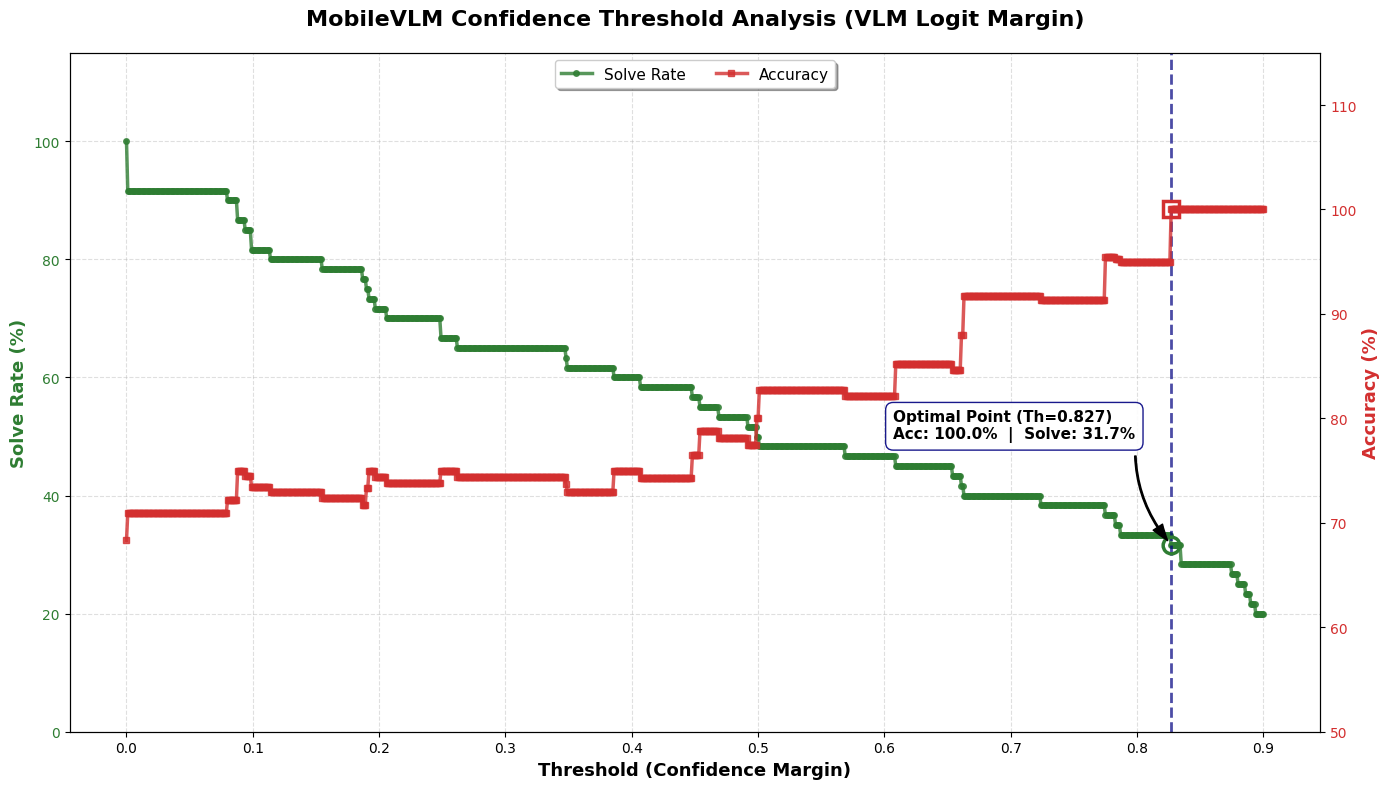

✅ 그래프 저장: vlm_threshold_analysis.png

 Threshold   Solve Rate   Solved   Accuracy
     0.000       100.0%       60      68.3%
     0.100        81.7%       49      73.5%
     0.200        71.7%       43      74.4%
     0.300        65.0%       39      74.4%
     0.400        60.0%       36      75.0%
     0.500        50.0%       30      80.0%
     0.600        46.7%       28      82.1%
     0.700        40.0%       24      91.7%
     0.800        33.3%       20      95.0%
     0.900        20.0%       12     100.0%

  Optimal Point : Acc=100.0%  Solve=31.7%  (th=0.827)
  Best Accuracy : 100.0%  Solve=31.7%  (th=0.827)
  CSV 저장      : vlm_threshold_train_analysis.csv


In [ ]:
# =====================================================================
# Cell 9: Threshold 분석
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def analyze_and_plot(sim_csv, train_csv, start=0.0, end=0.9, step=0.001, target_th=0.3):
    sim_df = pd.read_csv(sim_csv)
    ans_df = pd.read_csv(train_csv)
    df     = pd.merge(sim_df, ans_df[['ID','answer']], on='ID')
    total  = len(df)

    results = []
    for th in np.arange(start, end + 1e-9, step):
        solved = correct = 0
        for _, row in df.iterrows():
            sims   = [row['Sim_A'], row['Sim_B'], row['Sim_C'], row['Sim_D']]
            s_sum  = sum(sims)
            probs  = [s/s_sum for s in sims] if s_sum else [0.25]*4
            ranked = sorted(zip(['A','B','C','D'], probs), key=lambda x: x[1], reverse=True)
            margin = ranked[0][1] - ranked[1][1]
            if margin >= th:
                solved += 1
                if ranked[0][0] == str(row['answer']).strip().upper():
                    correct += 1
        results.append({
            'Threshold':  round(th, 3),
            'Solved':     solved,
            'Solve_Rate': round(solved / total * 100, 2),
            'Accuracy':   round(correct / solved * 100 if solved else 0, 2)
        })

    res_df = pd.DataFrame(results)
    res_df.to_csv("vlm_threshold_train_analysis.csv", index=False, encoding='utf-8-sig')

    # ── 최적점 & Best Accuracy 계산 ──────────────────────────────────
    # target_th에 가장 가까운 행
    target_idx = (res_df['Threshold'] - target_th).abs().argsort().iloc[0]
    target_row = res_df.loc[target_idx]

    # Best Accuracy 행
    best_idx = res_df['Accuracy'].idxmax()
    best     = res_df.loc[best_idx]

    # ── 시각화 ──────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Solve Rate (좌축)
    color1 = '#2E7D32'
    ax1.set_xlabel('Threshold (Confidence Margin)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Solve Rate (%)', color=color1, fontsize=13, fontweight='bold')
    line1 = ax1.plot(res_df['Threshold'], res_df['Solve_Rate'],
                     color=color1, marker='o', label='Solve Rate',
                     linewidth=2.5, markersize=4, alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, 115)
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Accuracy (우축)
    color2 = '#D32F2F'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy (%)', color=color2, fontsize=13, fontweight='bold')
    line2 = ax2.plot(res_df['Threshold'], res_df['Accuracy'],
                     color=color2, marker='s', label='Accuracy',
                     linewidth=2.5, markersize=4, alpha=0.8)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(50, 115)

    # ── Optimal Point (target_th) 강조 ───────────────────────────────
    actual_th     = target_row['Threshold']
    target_acc    = target_row['Accuracy']
    target_solve  = target_row['Solve_Rate']

    ax1.axvline(x=actual_th, color='navy', linestyle='--', linewidth=2, alpha=0.7)
    ax1.plot(actual_th, target_solve, 'o', color='#2E7D32',
             markersize=12, fillstyle='none', markeredgewidth=2.5)
    ax2.plot(actual_th, target_acc,   's', color='#D32F2F',
             markersize=12, fillstyle='none', markeredgewidth=2.5)

    ax1.annotate(
        f'Optimal Point (Th={actual_th:.3f})\nAcc: {target_acc:.1f}%  |  Solve: {target_solve:.1f}%',
        xy=(actual_th, target_solve),
        xytext=(actual_th - 0.22, target_solve + 18),
        arrowprops=dict(facecolor='black', shrink=0.05,
                        width=1, headwidth=8, connectionstyle="arc3,rad=.2"),
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="navy", alpha=0.9)
    )

    # ── Best Accuracy 지점 강조 (target_th와 다를 때만) ──────────────
    if best['Threshold'] != actual_th:
        ax2.plot(best['Threshold'], best['Accuracy'], '*',
                 color='#FF6F00', markersize=14, zorder=5, label='Best Accuracy')
        ax2.annotate(
            f"Best Acc\nth={best['Threshold']:.3f}\n{best['Accuracy']:.1f}% (Solve={best['Solve_Rate']:.1f}%)",
            xy=(best['Threshold'], best['Accuracy']),
            xytext=(best['Threshold'] + 0.03, best['Accuracy'] - 14),
            arrowprops=dict(arrowstyle='->', color='#FF6F00', lw=1.5),
            fontsize=10, color='#FF6F00',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#FF6F00", alpha=0.9)
        )

    # ── 범례 & 제목 ───────────────────────────────────────────────────
    lines  = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', frameon=True, shadow=True, ncol=2, fontsize=11)

    plt.title('MobileVLM Confidence Threshold Analysis (VLM Logit Margin)',
              fontsize=16, pad=20, fontweight='bold')
    plt.xticks(np.arange(0, end + 0.1, 0.1))
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/vlm_threshold_analysis.png", dpi=300)
    plt.show()
    print("✅ 그래프 저장: vlm_threshold_analysis.png")

    # ── 요약 출력 ────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"{'Threshold':>10} {'Solve Rate':>12} {'Solved':>8} {'Accuracy':>10}")
    print(f"{'='*50}")
    for th_show in np.arange(0, 1, 0.1):
        row = res_df[res_df['Threshold'] == round(th_show, 3)]
        if not row.empty:
            r      = row.iloc[0]
            marker = " ◀ Optimal" if abs(th_show - target_th) < 1e-6 else ""
            print(f"{r['Threshold']:>10.3f} {r['Solve_Rate']:>11.1f}% "
                  f"{int(r['Solved']):>8d} {r['Accuracy']:>9.1f}%{marker}")
    print(f"{'='*50}")
    print(f"\n  Optimal Point : Acc={target_acc:.1f}%  Solve={target_solve:.1f}%  (th={actual_th:.3f})")
    print(f"  Best Accuracy : {best['Accuracy']:.1f}%  Solve={best['Solve_Rate']:.1f}%  (th={best['Threshold']:.3f})")
    print(f"  CSV 저장      : vlm_threshold_train_analysis.csv")

    return res_df

# ── 실행 ─────────────────────────────────────────────────────────────
sim_csv   = "/content/vlm_logit_similarities_train.csv"
train_csv = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"

res_df = analyze_and_plot(
    sim_csv   = sim_csv,
    train_csv = train_csv,
    start     = 0.0,
    end       = 0.9,
    step      = 0.001,
    target_th = 0.827
)

> # **STAGE 1. Clip 유사도를 활용해서 Test Data 풀기**

In [ ]:
# =====================================================================
# CLIP 기반 Test 데이터 추론 (full_clip 사용)
# =====================================================================
import torch
import torch.nn.functional as F
import pandas as pd
import os
from tqdm import tqdm
from PIL import Image
from transformers import CLIPTokenizer

# ── 경로 설정 ────────────────────────────────────────────────────────
test_csv_path  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test.csv"
test_image_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test_input_images/"
test_df        = pd.read_csv(test_csv_path)

clip_ckpt      = "openai/clip-vit-large-patch14-336"

# ── CLIP tokenizer 로드 ───────────────────────────────────────────────
clip_tokenizer = CLIPTokenizer.from_pretrained(clip_ckpt)

full_clip.eval()

# ── 이미지 인코딩 ────────────────────────────────────────────────────
def encode_image_clip(image_path):
    """이미지 → CLIP visual embedding (L2 정규화)"""
    image = Image.open(image_path).convert('RGB')
    pixel_values = image_processor.preprocess(
        image, return_tensors='pt'
    )['pixel_values'].to("cuda", dtype=torch.bfloat16)

    with torch.no_grad():
        vision_out   = full_clip.vision_model(pixel_values=pixel_values)
        pooled       = vision_out.pooler_output              # (1, D_vision)
        image_embeds = full_clip.visual_projection(pooled)   # (1, D_clip)
        image_embeds = F.normalize(image_embeds.float(), dim=-1)
    return image_embeds  # (1, D_clip)

# ── 텍스트 인코딩 ────────────────────────────────────────────────────
def encode_texts_clip(texts):
    """
    texts : List[str]  — 각 선택지 텍스트
    return: (N, D_clip) L2 정규화된 text embeddings
    """
    inputs = clip_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=77,
        return_tensors='pt'
    ).to("cuda")

    with torch.no_grad():
        text_out    = full_clip.text_model(**inputs)
        pooled      = text_out.pooler_output                 # (N, D_text)
        text_embeds = full_clip.text_projection(pooled)      # (N, D_clip)
        text_embeds = F.normalize(text_embeds.float(), dim=-1)
    return text_embeds  # (N, D_clip)

# ── CLIP 유사도 기반 추론 ─────────────────────────────────────────────
def get_clip_scores(image_path, question, choices):
    if not os.path.exists(image_path):
        return [0.25, 0.25, 0.25, 0.25]

    try:
        image_embeds = encode_image_clip(image_path)
    except Exception as e:
        print(f"[이미지 인코딩 실패] {image_path}: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    texts = [
        f"Question: {question} Answer: {choices[k]}"
        for k in ['A', 'B', 'C', 'D']
    ]

    try:
        text_embeds = encode_texts_clip(texts)
    except Exception as e:
        print(f"[텍스트 인코딩 실패]: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    logit_scale = full_clip.logit_scale.exp().float()
    logits      = logit_scale * (image_embeds @ text_embeds.T)
    probs       = F.softmax(logits[0], dim=-1).detach().cpu().numpy()  # ← detach() 추가

    return probs.tolist()

# ── 추론 루프 ─────────────────────────────────────────────────────────
records = []
print(f"🚀 [Test Dataset] {len(test_df)}개 문항 CLIP 추론 시작...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_path = os.path.join(test_image_dir, f"{row['ID']}.jpg")
    choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
    scores   = get_clip_scores(img_path, row['Question'], choices)
    records.append({
        "ID":    row["ID"],
        "Sim_A": scores[0], "Sim_B": scores[1],
        "Sim_C": scores[2], "Sim_D": scores[3]
    })

# ── 결과 저장 ─────────────────────────────────────────────────────────
out_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/vlm_logit_similarities_test.csv"
pd.DataFrame(records).to_csv(out_path, index=False)
print(f"\n✅ 완료! '{out_path}'에 저장되었습니다. ({len(records)}건)")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


🚀 [Test Dataset] 852개 문항 CLIP 추론 시작...


100%|██████████| 852/852 [05:13<00:00,  2.72it/s]


✅ 완료! 'vlm_logit_similarities_test.csv'에 저장되었습니다. (852건)


In [ ]:
# =====================================================================
# Threshold 기반 CLIP 답변 확정 / 미확정 분류
# =====================================================================
import pandas as pd

THRESHOLD = 0.827

sim_csv   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/vlm_logit_similarities_test.csv"
test_csv  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test.csv"

sim_df  = pd.read_csv(sim_csv)
test_df = pd.read_csv(test_csv)
df      = pd.merge(sim_df, test_df[['ID']], on='ID')

# ── threshold 적용 ────────────────────────────────────────────────────
clip_solved   = []   # CLIP으로 확정된 문항
clip_unsolved = []   # 다른 방법이 필요한 문항

for _, row in df.iterrows():
    sims   = [row['Sim_A'], row['Sim_B'], row['Sim_C'], row['Sim_D']]
    s_sum  = sum(sims)
    probs  = [s / s_sum for s in sims] if s_sum else [0.25] * 4
    ranked = sorted(zip(['A', 'B', 'C', 'D'], probs), key=lambda x: x[1], reverse=True)
    margin = ranked[0][1] - ranked[1][1]

    entry = {
        'ID':         row['ID'],
        'pred':       ranked[0][0],
        'margin':     round(margin, 4),
        'prob_A':     round(probs[0], 4),
        'prob_B':     round(probs[1], 4),
        'prob_C':     round(probs[2], 4),
        'prob_D':     round(probs[3], 4),
    }

    if margin >= THRESHOLD:
        clip_solved.append(entry)
    else:
        clip_unsolved.append(entry)

clip_solved_df   = pd.DataFrame(clip_solved)
clip_unsolved_df = pd.DataFrame(clip_unsolved)

# ── 저장 ──────────────────────────────────────────────────────────────
solved_path   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_solved_test.csv"
unsolved_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_unsolved_test.csv"

clip_solved_df.to_csv(solved_path,   index=False)
clip_unsolved_df.to_csv(unsolved_path, index=False)

# ── 요약 출력 ─────────────────────────────────────────────────────────
total = len(df)
print(f"{'='*50}")
print(f"  Threshold     : {THRESHOLD}")
print(f"  전체 문항     : {total}")
print(f"  CLIP 확정     : {len(clip_solved_df)}  ({len(clip_solved_df)/total*100:.1f}%)")
print(f"  추가 필요     : {len(clip_unsolved_df)}  ({len(clip_unsolved_df)/total*100:.1f}%)")
print(f"{'='*50}")
print(f"\n  CLIP 확정 ID 목록 ({len(clip_solved_df)}개):")
print(f"  {clip_solved_df['ID'].tolist()}")
print(f"\n  추가 필요 ID 목록 ({len(clip_unsolved_df)}개):")
print(f"  {clip_unsolved_df['ID'].tolist()}")
print(f"\n  저장 완료:")
print(f"    {solved_path}")
print(f"    {unsolved_path}")

  Threshold     : 0.827
  전체 문항     : 852
  CLIP 확정     : 485  (56.9%)
  추가 필요     : 367  (43.1%)

  CLIP 확정 ID 목록 (485개):
  ['TEST_000', 'TEST_001', 'TEST_003', 'TEST_004', 'TEST_005', 'TEST_007', 'TEST_009', 'TEST_010', 'TEST_011', 'TEST_012', 'TEST_016', 'TEST_017', 'TEST_019', 'TEST_021', 'TEST_022', 'TEST_023', 'TEST_026', 'TEST_027', 'TEST_028', 'TEST_031', 'TEST_032', 'TEST_034', 'TEST_035', 'TEST_037', 'TEST_038', 'TEST_039', 'TEST_040', 'TEST_041', 'TEST_043', 'TEST_045', 'TEST_046', 'TEST_049', 'TEST_050', 'TEST_052', 'TEST_054', 'TEST_056', 'TEST_057', 'TEST_060', 'TEST_063', 'TEST_065', 'TEST_068', 'TEST_070', 'TEST_072', 'TEST_073', 'TEST_077', 'TEST_079', 'TEST_081', 'TEST_083', 'TEST_086', 'TEST_087', 'TEST_088', 'TEST_089', 'TEST_090', 'TEST_091', 'TEST_093', 'TEST_096', 'TEST_099', 'TEST_102', 'TEST_105', 'TEST_106', 'TEST_107', 'TEST_109', 'TEST_110', 'TEST_111', 'TEST_112', 'TEST_114', 'TEST_115', 'TEST_116', 'TEST_117', 'TEST_118', 'TEST_120', 'TEST_121', 'TEST_122'

# **STAGE 2. Solving remaining test data with mobile VLM**

> Prompt 1단계: 이미지 분석 (Captioning) 프롬프트
- A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: <image_tokens> Analyze the image in a comprehensive and detailed manner. ASSISTANT:

> Prompt 2단계: 분석 내용을 바탕으로 퀴즈 풀기
- A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: <image_tokens> Analyze the image in a comprehensive and detailed manner. ASSISTANT: [모델이 생성한 상세 분석 내용] </s>USER: {현재 문제} Choices: A. {A 내용} B. {B 내용} C. {C 내용} D. {D 내용} Answer with only the alphabet of the correct option. ASSISTANT:

In [24]:
# =====================================================================
# Pruned MobileVLM으로 clip_unsolved 문항 풀기
# =====================================================================
import torch
import os
import pandas as pd
from tqdm import tqdm
from PIL import Image
from transformers import CLIPImageProcessor
from mobilevlm.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from mobilevlm.utils import tokenizer_image_token
from mobilevlm.conversation import conv_templates

# ── 이미지 프로세서 설정 ──────────────────────────────────────────────
image_processor = CLIPImageProcessor.from_pretrained(
    "openai/clip-vit-large-patch14",
    size={"height": 336, "width": 336},
    crop_size={"height": 336, "width": 336}
)
print(f"✅ 이미지 프로세서: {image_processor.size}")

# ── 경로 설정 ────────────────────────────────────────────────────────
test_csv_path    = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test.csv"
test_image_dir   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test_input_images/"
unsolved_path    = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_unsolved_test.csv"

test_df     = pd.read_csv(test_csv_path)
unsolved_df = pd.read_csv(unsolved_path)

# unsolved ID 목록으로 test_df 필터링 → 질문/선택지 정보 합치기
unsolved_ids = set(unsolved_df['ID'].tolist())
target_df    = test_df[test_df['ID'].isin(unsolved_ids)].reset_index(drop=True)
print(f"✅ 풀 문항 수: {len(target_df)}개  (전체 {len(test_df)}개 중)")

# ── 추론 함수 (pruned_model 사용) ────────────────────────────────────
def solve_with_pruned_vlm(image_path, question, choices):
    """
    pruned_model (LLMPruner LlamaForCausalLM + vision 모듈 주입)으로
    2단계 추론 수행
    """
    if not os.path.exists(image_path):
        print(f"⚠️ 파일 없음: {image_path}")
        return "A"

    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = image_processor.preprocess(
            image, return_tensors='pt'
        )['pixel_values'].to("cuda", dtype=torch.bfloat16)
    except Exception as e:
        print(f"[이미지 로드 실패] {image_path}: {e}")
        return "A"

    # ── 이미지 인코딩 (vision_tower → mm_projector) ──────────────
    try:
        with torch.no_grad():
            image_features = _clip_wrapper(image_tensor)          # CLIPVisionTower
            image_features = _mm(image_features)                  # LDPNetProjector
    except Exception as e:
        print(f"[비전 인코딩 실패] {image_path}: {e}")
        return "A"

    def run_generate(conv, max_new_tokens, do_sample, temperature=None):
        """conv 기반 inputs_embeds 생성 후 pruned_model.generate()"""
        prompt   = conv.get_prompt()
        input_ids = tokenizer_image_token(
            prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
        ).unsqueeze(0).to("cuda")

        # IMAGE_TOKEN 위치에 image_features 삽입
        ids = input_ids[0]
        img_positions = (ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]

        if len(img_positions) > 0:
            pos        = img_positions[0].item()
            before_emb = _embed(ids[:pos]).unsqueeze(0)
            after_emb  = _embed(ids[pos+1:]).unsqueeze(0)
            inputs_embeds = torch.cat([before_emb, image_features, after_emb], dim=1)
        else:
            inputs_embeds = _embed(ids).unsqueeze(0)

        gen_kwargs = dict(
            inputs_embeds=inputs_embeds,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            use_cache=False,
            pad_token_id=tokenizer.pad_token_id
        )
        if do_sample and temperature is not None:
            gen_kwargs['temperature'] = temperature

        with torch.inference_mode():
            output_ids = pruned_model.generate(**gen_kwargs)

        # generate()가 inputs_embeds 길이를 알 수 없으므로 전체 디코딩
        decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
        return decoded

    # ── 1단계: 이미지 분석 ───────────────────────────────────────
    analysis_q = "Analyze the image in a comprehensive and detailed manner."
    conv = conv_templates["vicuna_v1"].copy()
    conv.append_message(conv.roles[0], f"{DEFAULT_IMAGE_TOKEN}\n{analysis_q}")
    conv.append_message(conv.roles[1], None)

    analysis_res = run_generate(conv, max_new_tokens=256, do_sample=True, temperature=0.7)

    # ── 2단계: 분석 결과 기반 퀴즈 ──────────────────────────────
    quiz_q = (
        f"{question}\n"
        f"Choices:\nA. {choices['A']}\nB. {choices['B']}\n"
        f"C. {choices['C']}\nD. {choices['D']}\n"
        f"Answer with only the alphabet of the correct option."
    )
    conv.messages[-1][1] = analysis_res   # 1단계 답변 채우기
    conv.append_message(conv.roles[0], quiz_q)
    conv.append_message(conv.roles[1], None)

    final_answer = run_generate(conv, max_new_tokens=5, do_sample=False)

    for char in final_answer:
        if char.upper() in ['A', 'B', 'C', 'D']:
            return char.upper()
    return "A"

# ── embed_tokens 단축 참조 ───────────────────────────────────────────
_clip_wrapper = pruned_model.model.vision_tower
_mm           = pruned_model.model.mm_projector.to("cuda", dtype=torch.bfloat16)
_embed        = pruned_model.model.embed_tokens

if hasattr(_clip_wrapper, 'is_loaded') and not _clip_wrapper.is_loaded:
    _clip_wrapper.load_model()
_clip_wrapper = _clip_wrapper.to("cuda", dtype=torch.bfloat16).eval()

# ── 추론 루프 ─────────────────────────────────────────────────────────
records = []
print(f"🚀 Pruned MobileVLM 추론 시작 ({len(target_df)}개)...")

for _, row in tqdm(target_df.iterrows(), total=len(target_df)):
    img_path = os.path.join(test_image_dir, f"{row['ID']}.jpg")
    choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
    pred     = solve_with_pruned_vlm(img_path, row['Question'], choices)
    records.append({"ID": row["ID"], "answer": pred})

pruned_result_df = pd.DataFrame(records)

# ── 저장 ──────────────────────────────────────────────────────────────
out_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/pruned_vlm_unsolved_results.csv"
pruned_result_df.to_csv(out_path, index=False)
print(f"\n✅ 저장 완료: {out_path}  ({len(pruned_result_df)}건)")
print(pruned_result_df.head(10).to_string(index=False))

✅ 이미지 프로세서: {'height': 336, 'width': 336}
✅ 풀 문항 수: 367개  (전체 852개 중)
🚀 Pruned MobileVLM 추론 시작 (367개)...


100%|██████████| 367/367 [08:57<00:00,  1.47s/it]


✅ 저장 완료: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/pruned_vlm_unsolved_results.csv  (367건)
      ID answer
TEST_002      B
TEST_006      B
TEST_008      D
TEST_013      C
TEST_014      A
TEST_015      A
TEST_018      A
TEST_020      D
TEST_024      A
TEST_025      A


# **Final Merge**

In [29]:
# =====================================================================
# 최종 답안 합치기 + 채점
# =====================================================================
import pandas as pd

# ── 경로 설정 ────────────────────────────────────────────────────────
sample_sub_path  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/sample_submission.csv"
solved_path      = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_solved_test.csv"
unsolved_path    = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/pruned_vlm_unsolved_results.csv"
final_out_path   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/final_submission.csv"
gt_path          = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/TestWithAnswer.csv"

# ── 1. 각 결과 로드 ───────────────────────────────────────────────────
sample_df  = pd.read_csv(sample_sub_path)                        # 제출 형식 기준
solved_df  = pd.read_csv(solved_path)[['ID', 'pred']].rename(columns={'pred': 'answer'})
unsolved_df = pd.read_csv(unsolved_path)[['ID', 'answer']]

# ── 2. 두 결과 합치기 ────────────────────────────────────────────────
combined_df = pd.concat([solved_df, unsolved_df], ignore_index=True)

# sample_submission 순서에 맞게 정렬
final_df = sample_df[['ID']].merge(combined_df, on='ID', how='left')

# 누락된 ID 검사
missing = final_df['answer'].isna().sum()
if missing > 0:
    print(f"⚠️ 누락 문항 {missing}개")

final_df.to_csv(final_out_path, index=False)
print(f"\n✅ 최종 답안 저장: {final_out_path}  ({len(final_df)}건)")
print(f"   CLIP : {len(solved_df)}건  /  Pruned MobileVLM : {len(unsolved_df)}건")
print(final_df.head(10).to_string(index=False))


✅ 최종 답안 저장: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/final_submission.csv  (852건)
   CLIP : 485건  /  Pruned MobileVLM : 367건
      ID answer
TEST_000      B
TEST_001      A
TEST_002      B
TEST_003      C
TEST_004      C
TEST_005      C
TEST_006      B
TEST_007      D
TEST_008      D
TEST_009      C


In [26]:
# ── 3. 채점 ──────────────────────────────────────────────────────────
def score_submission(sub_csv, gt_csv):
    try:
        sub_df = pd.read_csv(sub_csv, encoding='utf-8-sig')
        gt_df  = pd.read_csv(gt_csv,  encoding='utf-8-sig')
    except Exception:
        sub_df = pd.read_csv(sub_csv, encoding='cp949')
        gt_df  = pd.read_csv(gt_csv,  encoding='cp949')

    # BOM 제거 + 컬럼명 대문자 통일
    sub_df.columns = [c.replace('\ufeff', '').strip().upper() for c in sub_df.columns]
    gt_df.columns  = [c.replace('\ufeff', '').strip().upper() for c in gt_df.columns]

    print(f"  Sub 컬럼  : {list(sub_df.columns)}")
    print(f"  GT  컬럼  : {list(gt_df.columns)}")

    # ID 컬럼 보장
    for df_, name in [(sub_df, 'sub'), (gt_df, 'gt')]:
        if 'ID' not in df_.columns:
            df_.rename(columns={df_.columns[0]: 'ID'}, inplace=True)
            print(f"⚠️ [{name}] 첫 번째 컬럼을 ID로 지정")

    merged = pd.merge(sub_df, gt_df[['ID', 'ANSWER']], on='ID', suffixes=('_PRED', '_GT'))
    merged['IS_CORRECT'] = (
        merged['ANSWER_PRED'].astype(str).str.strip().str.upper() ==
        merged['ANSWER_GT'].astype(str).str.strip().str.upper()
    )

    total    = len(merged)
    correct  = merged['IS_CORRECT'].sum()
    accuracy = correct / total * 100 if total > 0 else 0

    # 방법별 정확도
    clip_ids    = set(solved_df['ID'])
    pruned_ids  = set(unsolved_df['ID'])

    clip_rows   = merged[merged['ID'].isin(clip_ids)]
    pruned_rows = merged[merged['ID'].isin(pruned_ids)]

    clip_acc   = clip_rows['IS_CORRECT'].mean() * 100   if len(clip_rows)   else 0
    pruned_acc = pruned_rows['IS_CORRECT'].mean() * 100 if len(pruned_rows) else 0

    print("\n" + "=" * 45)
    print(f"  🎯 채점 결과 리포트")
    print("-" * 45)
    print(f"  파일          : {sub_csv.split('/')[-1]}")
    print(f"  총 문항       : {total}개")
    print(f"  정답          : {correct}개")
    print(f"  최종 정확도   : {accuracy:.2f}%")
    print("-" * 45)
    print(f"  [CLIP 확정]   : {len(clip_rows)}개  →  정확도 {clip_acc:.2f}%")
    print(f"  [Pruned VLM]  : {len(pruned_rows)}개  →  정확도 {pruned_acc:.2f}%")
    print("=" * 45)

    return merged

scored_df = score_submission(final_out_path, gt_path)

  Sub 컬럼  : ['ID', 'ANSWER']
  GT  컬럼  : ['ID', 'IMG_PATH', 'QUESTION', 'A', 'B', 'C', 'D', 'ANSWER']

  🎯 채점 결과 리포트
---------------------------------------------
  파일          : final_submission.csv
  총 문항       : 852개
  정답          : 684개
  최종 정확도   : 80.28%
---------------------------------------------
  [CLIP 확정]   : 485개  →  정확도 92.37%
  [Pruned VLM]  : 367개  →  정확도 64.31%
